# ДЗ 2: классификация новостей с помощью эмбеддингов

продолжаем работу с датасетом lenta-ru-news из прошлой домашки. теперь будем использовать word2vec эмбеддинги для векоризации текстов вместо bag-of-words.

план:
1. подготовка данных (из дз1)
2. обучение своих word2vec эмбеддингов
3. загрузка предобученных (navec + rusvectores)
4. логистическая регрессия с тремя типами эмбеддингов
5. улучшение через TF-IDF взвешивание
6. финальное сравнение и выводы

## 0. установка и импорты

In [1]:
%pip install corus pymorphy3 scikit-learn pandas numpy matplotlib seaborn nltk tqdm gensim navec --quiet

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import re
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import pymorphy3
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score
)
from sklearn.decomposition import PCA

from corus import load_lenta
from gensim.models import Word2Vec

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

warnings.filterwarnings('ignore')
nltk.download('stopwords', quiet=True)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. загрузка и подготовка данных

берем тот же датасет что и в дз1, предобработка тоже такая же - лемматизация, удаление стоп-слов, чистка от мусора.

In [3]:
DATA_PATH = 'lenta-ru-news.csv.gz'

!curl -L -o {DATA_PATH} https://github.com/yutkin/Lenta.Ru-News-Dataset/releases/download/v1.0/lenta-ru-news.csv.gz
print(f'размер файла: {os.path.getsize(DATA_PATH) / 1024 / 1024:.1f} MB')

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  502M  100  502M    0     0   637k      0  0:13:28  0:13:28 --:--:--  594k 0:03:49  0:00:12  0:03:37  605k520k      0  0:05:38  0:00:22  0:05:16  613k:06:31  0:00:28  0:06:03  569k 0:07:04  0:00:33  0:06:31  620kk      0  0:08:44  0:00:54  0:07:50  627k25  0:01:07  0:08:18  596k:09:48  0:01:16  0:08:32  585k    0  0:10:38  0:01:45  0:08:53  603k 0   781k      0  0:10:58  0:02:01  0:08:57  599k02:14  0:09:00  554k:11:27  0:02:25  0:09:02  579k 0:11:36  0:02:37  0:08:59  617k3:25  0:08:42  540k    0   706k      0  0:12:08  0:03:28  0:08:40  590k0   697k      0  0:12:18  0:03:50  0:08:28  577k:03:57  0:08:24  609k8:18  597k:12:30  0:04:25  0:08:05  637k4:28  0:08:03  568k39  0:04:58  0:07:41  617k0  0:07:40  615k:06  0:07:35  618k675k      0  0:12:41  

In [4]:
records = load_lenta(DATA_PATH)

data = []
for record in tqdm(records, desc='загрузка'):
    data.append({
        'title': record.title,
        'text': record.text,
        'topic': record.topic,
    })

df = pd.DataFrame(data)
print(f'всего записей: {len(df)}')
print(f'топиков: {df["topic"].nunique()}')
df.head()

загрузка: 0it [00:00, ?it/s]

всего записей: 739351
топиков: 24


,title,text,topic
0,Названы регионы России с самой высокой смертно...,Вице-премьер по социальным вопросам Татьяна Го...,Россия
1,Австрия не представила доказательств вины росс...,Австрийские правоохранительные органы не предс...,Спорт
2,Обнаружено самое счастливое место на планете,Сотрудники социальной сети Instagram проанализ...,Путешествия
3,В США раскрыли сумму расходов на расследование...,С начала расследования российского вмешательст...,Мир
4,Хакеры рассказали о планах Великобритании зами...,Хакерская группировка Anonymous опубликовала н...,Мир


In [5]:
SAMPLE_SIZE = 100_000

topic_counts = df['topic'].value_counts()
valid_topics = topic_counts[topic_counts >= 10].index
df = df[df['topic'].isin(valid_topics)]

df_sample, _ = train_test_split(
    df,
    train_size=SAMPLE_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['topic'],
)
df_sample = df_sample.reset_index(drop=True)
print(f'размер выборки: {len(df_sample)}')

размер выборки: 100000


### предобработка

все как в прошлый раз - нижний регистр, чистка от url/html/спецсимволов, лемматизация через pymorphy3, удаление стоп-слов.

In [6]:
morph = pymorphy3.MorphAnalyzer()
STOPWORDS = set(stopwords.words('russian'))

RE_URL = re.compile(r'https?://\S+|www\.\S+')
RE_EMAIL = re.compile(r'\S+@\S+')
RE_HTML = re.compile(r'<[^>]+>')
RE_NON_ALPHA = re.compile(r'[^\u0430-\u044f\u0451a-z\s]')
RE_WHITESPACE = re.compile(r'\s+')

_lemma_cache = {}


def lemmatize_word(word):
    if word not in _lemma_cache:
        _lemma_cache[word] = morph.parse(word)[0].normal_form
    return _lemma_cache[word]


def preprocess_text(text):
    text = text.lower()
    text = RE_URL.sub(' ', text)
    text = RE_EMAIL.sub(' ', text)
    text = RE_HTML.sub(' ', text)
    text = RE_NON_ALPHA.sub(' ', text)
    text = RE_WHITESPACE.sub(' ', text).strip()
    tokens = [
        lemmatize_word(t)
        for t in text.split()
        if t not in STOPWORDS and len(t) > 1
    ]
    return ' '.join(tokens)

In [7]:
%%time
tqdm.pandas(desc='предобработка')

df_sample['full_text'] = (
    df_sample['title'].fillna('') + ' ' + df_sample['text'].fillna('')
)
df_sample['processed_text'] = df_sample['full_text'].progress_apply(preprocess_text)

print(f'\nпример:')
print(f'исходный:     {df_sample["full_text"].iloc[0][:150]}...')
print(f'обработанный: {df_sample["processed_text"].iloc[0][:150]}...')

предобработка:   0%|          | 0/100000 [00:00<?, ?it/s]


пример:
исходный:     Государственный департамент США не устраивают бумажные призывы Арафата Государственный департамент США заявил, что заявления Арафата, призывающего пал...
обработанный: государственный департамент сша устраивать бумажный призыв арафат государственный департамент сша заявить заявление арафат призывать палестинец прекра...
CPU times: user 33.2 s, sys: 446 ms, total: 33.6 s
Wall time: 33.6 s


### разделение на train / val / test (60/20/20)

стратифицированный сплит - чтобы пропорции классов сохранились во всех частях.

In [8]:
X = df_sample['processed_text']
y = df_sample['topic']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

print(f'train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}')
print(f'\nпропорции классов (train):')
print(y_train.value_counts(normalize=True).head())

train: 60000, val: 20000, test: 20000

пропорции классов (train):
topic
Россия       0.217117
Мир          0.184867
Экономика    0.107583
Спорт        0.087133
Культура     0.072767
Name: proportion, dtype: float64


## 2. обучение Word2Vec (gensim)

обучаем свою модель word2vec на тренировочных текстах. гиперпараметры:

- **vector_size=300** - размерность эмбеддингов. 300 это стандарт, плюс navec и rusvectores тоже 300d, так что будет честное сравнение
- **window=5** - окно контекста (5 слов в каждую сторону). для новостных текстов нормально - не слишком узко и не слишком широко
- **min_count=5** - минимальная частота слова. убираем совсем редкие слова (опечатки, имена), чтобы не засорять словарь
- **sg=1** - skip-gram вместо CBOW. skip-gram обычно лучше работает для редких слов и на больших корпусах
- **epochs=10** - 10 эпох обучения, стандартное значение для word2vec
- **seed=42** - для воспроизводимости

In [9]:
%%time
tokenized_train = [text.split() for text in X_train]

w2v_model = Word2Vec(
    sentences=tokenized_train,
    vector_size=300,
    window=5,
    min_count=5,
    workers=4,
    sg=1,
    seed=RANDOM_STATE,
    epochs=10,
)

print(f'размер словаря: {len(w2v_model.wv)} слов')
print(f'размерность: {w2v_model.wv.vector_size}')

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

размер словаря: 49982 слов
размерность: 300
CPU times: user 9min 3s, sys: 2.02 s, total: 9min 5s
Wall time: 2min 18s


## 3. оценка качества эмбеддингов (intrinsic evaluation)

посмотрим, насколько адекватные получились эмбеддинги. используем `most_similar` и `doesnt_match` из gensim.

In [10]:
test_words = ['москва', 'путин', 'футбол', 'экономика', 'война']

for word in test_words:
    if word in w2v_model.wv:
        similar = w2v_model.wv.most_similar(word, topn=5)
        print(f'\n"{word}" - похожие слова:')
        for w, score in similar:
            print(f'  {w}: {score:.3f}')
    else:
        print(f'"{word}" нет в словаре')


"москва" - похожие слова:
  столица: 0.559
  столичный: 0.549
  ясеневый: 0.495
  соловьиный: 0.488
  сзао: 0.487

"путин" - похожие слова:
  владимир: 0.696
  медведев: 0.609
  элбэгдорж: 0.580
  деофшоризация: 0.580
  энергозависимость: 0.551

"футбол" - похожие слова:
  сборная: 0.618
  футбольный: 0.608
  хоккей: 0.598
  фифа: 0.589
  чемпионат: 0.582

"экономика" - похожие слова:
  ввп: 0.621
  рецессия: 0.616
  инвестклимат: 0.584
  экономический: 0.583
  несырьевой: 0.563

"война" - похожие слова:
  развязывание: 0.588
  развязывать: 0.530
  шестидневный: 0.509
  окрепнуть: 0.506
  киноэпопея: 0.497


неплохо - "москва" дает связанные с ней слова (столица, столичный, районы), "путин" - политиков (медведев) и политическую лексику, "футбол" - спортивные слова (сборная, чемпионат, баскетбол). эмбеддинги вполне адекватные, семантика ловится.

теперь `doesnt_match` - ищем лишнее слово в группе:

In [11]:
test_groups = [
    ['москва', 'петербург', 'новосибирск', 'футбол'],
    ['путин', 'медведев', 'президент', 'хоккей'],
    ['рубль', 'доллар', 'евро', 'баскетбол'],
    ['экономика', 'бюджет', 'финансы', 'олимпиада'],
]

for group in test_groups:
    available = [w for w in group if w in w2v_model.wv]
    if len(available) >= 3:
        odd = w2v_model.wv.doesnt_match(available)
        print(f'{available} -> лишнее: "{odd}"')
    else:
        print(f'{group} - мало слов в словаре')

['москва', 'петербург', 'новосибирск', 'футбол'] -> лишнее: "футбол"
['путин', 'медведев', 'президент', 'хоккей'] -> лишнее: "хоккей"
['рубль', 'доллар', 'евро', 'баскетбол'] -> лишнее: "баскетбол"
['экономика', 'бюджет', 'финансы', 'олимпиада'] -> лишнее: "олимпиада"


doesnt_match тоже работает норм - модель правильно определяет лишнее слово в каждой группе. спортивные слова отделяются от городов, политиков и экономики.

визуализируем эмбеддинги через PCA - возьмем слова из разных категорий и посмотрим, как они группируются в 2D:

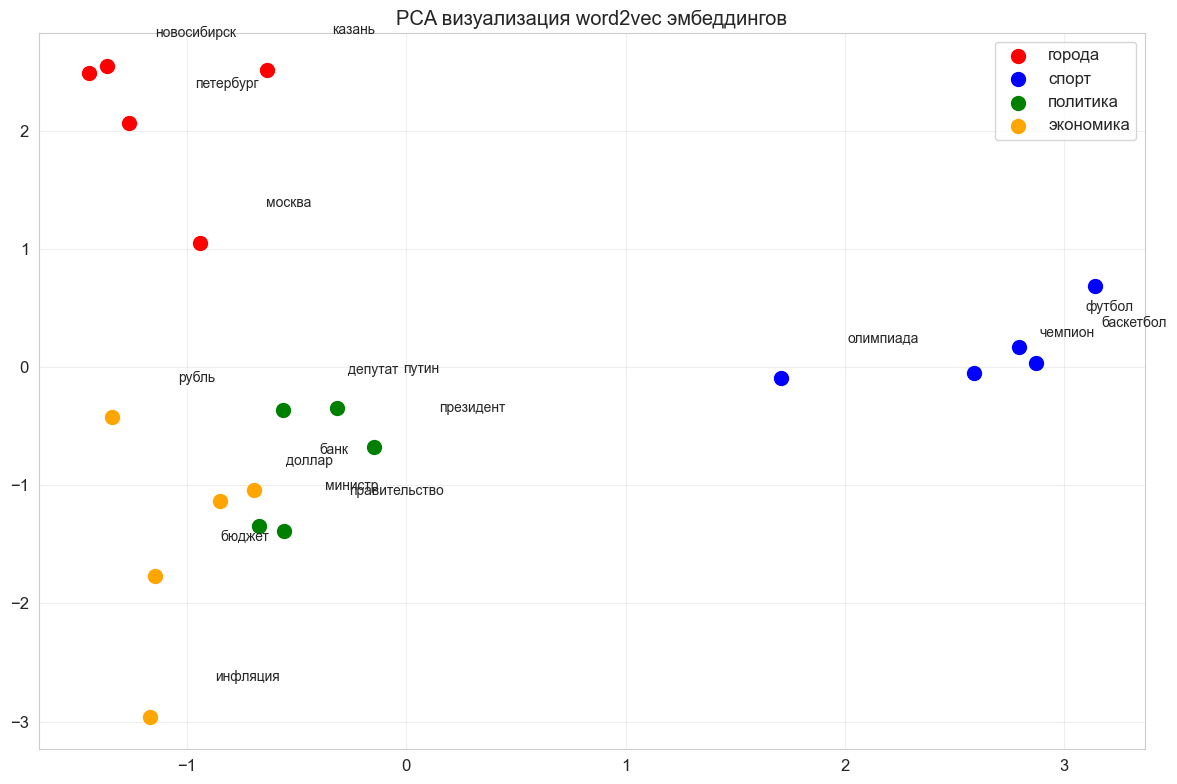

In [12]:
word_groups = {
    'города': ['москва', 'петербург', 'екатеринбург', 'новосибирск', 'казань'],
    'спорт': ['футбол', 'хоккей', 'баскетбол', 'олимпиада', 'чемпион'],
    'политика': ['путин', 'президент', 'правительство', 'министр', 'депутат'],
    'экономика': ['рубль', 'доллар', 'банк', 'бюджет', 'инфляция'],
}

colors_map = {'города': 'red', 'спорт': 'blue', 'политика': 'green', 'экономика': 'orange'}

all_words, all_vecs, all_labels = [], [], []
for group, words in word_groups.items():
    for w in words:
        if w in w2v_model.wv:
            all_words.append(w)
            all_vecs.append(w2v_model.wv[w])
            all_labels.append(group)

vecs_array = np.array(all_vecs)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(vecs_array)

plt.figure(figsize=(12, 8))
for i, (word, label) in enumerate(zip(all_words, all_labels)):
    plt.scatter(coords[i, 0], coords[i, 1], c=colors_map[label], s=100, zorder=2)
    plt.annotate(word, (coords[i, 0] + 0.3, coords[i, 1] + 0.3), fontsize=10)

legend_handles = [plt.scatter([], [], c=c, s=100, label=g) for g, c in colors_map.items()]
plt.legend(handles=legend_handles, fontsize=12)
plt.title('PCA визуализация word2vec эмбеддингов')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

на графике видно что слова из одной тематики группируются вместе - города отдельно, спорт отдельно, экономика отдельно. значит наш word2vec нормально обучился и улавливает семантику.

## 4. предобученные эмбеддинги

### 4.1 navec

[navec](https://github.com/natasha/navec) - компактные русские эмбеддинги от проекта natasha. берем модель hudlit (обучена на художественной литературе), 300d, словарь 500к слов.

In [13]:
from navec import Navec

NAVEC_PATH = 'navec_hudlit_v1_12B_500K_300d_100q.tar'

if not os.path.exists(NAVEC_PATH):
    !curl -L -o {NAVEC_PATH} https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

navec_model = Navec.load(NAVEC_PATH)
print('navec загружен (hudlit, 300d, 500k слов)')

navec загружен (hudlit, 300d, 500k слов)


### 4.2 rusvectores

загружаем предобученные эмбеддинги [rusvectores](https://rusvectores.org/) - word2vec обученный на национальном корпусе русского языка. скачиваем через gensim (может занять пару минут).

важный момент: в этой модели слова идут с POS-тегами (типа `слово_NOUN`), поэтому нужно убрать теги чтобы матчить с нашими текстами.

In [14]:
import gensim.downloader as api

rv_raw = api.load('word2vec-ruscorpora-300')
print(f'rusvectores загружен: {len(rv_raw.key_to_index)} слов (с POS-тегами)')

rv_vectors = {}
for word_pos in rv_raw.key_to_index:
    parts = word_pos.rsplit('_', 1)
    if len(parts) == 2:
        word = parts[0]
        if word and word not in rv_vectors:
            rv_vectors[word] = rv_raw[word_pos]

print(f'уникальных слов без тегов: {len(rv_vectors)}')

rusvectores загружен: 184973 слов (с POS-тегами)
уникальных слов без тегов: 183533


### сравнение покрытия словаря

посмотрим, какая доля слов из нашего корпуса покрывается каждым набором эмбеддингов. это важно - если эмбеддинг не знает слово, мы его просто пропускаем при усреднении.

In [15]:
all_tokens = set()
for text in X_train:
    all_tokens.update(text.split())

print(f'уникальных токенов в train: {len(all_tokens)}')

w2v_covered = sum(1 for t in all_tokens if t in w2v_model.wv)
navec_covered = sum(1 for t in all_tokens if t in navec_model)
rv_covered = sum(1 for t in all_tokens if t in rv_vectors)

print(f'\nпокрытие словаря:')
print(f'  word2vec (свой):   {w2v_covered}/{len(all_tokens)} ({w2v_covered/len(all_tokens)*100:.1f}%)')
print(f'  navec (hudlit):    {navec_covered}/{len(all_tokens)} ({navec_covered/len(all_tokens)*100:.1f}%)')
print(f'  rusvectores:       {rv_covered}/{len(all_tokens)} ({rv_covered/len(all_tokens)*100:.1f}%)')

уникальных токенов в train: 157686

покрытие словаря:
  word2vec (свой):   49982/157686 (31.7%)
  navec (hudlit):    61463/157686 (39.0%)
  rusvectores:       59129/157686 (37.5%)


свой word2vec покрывает меньше всего (~32%) - потому что обучали с min_count=5, и редкие слова отсеялись. зато те слова, которые он знает, он выучил именно на наших данных (новости).

navec (~39%) и rusvectores (~38%) покрывают больше за счет большого предобученного словаря, но домен другой (литература и корпус русского языка). посмотрим, скомпенсирует ли доменная специфика нашего w2v его меньший словарь.

## 5. LogisticRegression с тремя типами эмбеддингов

для каждого текста берем среднее эмбеддингов всех его слов - получаем вектор фиксированной длины (300), который подаем в логрег.

In [16]:
EMB_DIM = 300


def text_to_vector(text, *, embeddings, dim=EMB_DIM):
    """Среднее эмбеддингов слов текста."""
    tokens = text.split()
    vecs = [embeddings[w] for w in tokens if w in embeddings]
    if vecs:
        return np.mean(vecs, axis=0)
    return np.zeros(dim)


def vectorize_texts(texts, *, embeddings, dim=EMB_DIM):
    """Векторизация набора текстов через усреднение эмбеддингов."""
    return np.array([
        text_to_vector(text, embeddings=embeddings, dim=dim)
        for text in tqdm(texts, desc='векторизация')
    ])

In [17]:
%%time
print('векторизация через свой word2vec...')
X_train_w2v = vectorize_texts(X_train, embeddings=w2v_model.wv)
X_val_w2v = vectorize_texts(X_val, embeddings=w2v_model.wv)

print('\nвекторизация через navec...')
X_train_navec = vectorize_texts(X_train, embeddings=navec_model)
X_val_navec = vectorize_texts(X_val, embeddings=navec_model)

print('\nвекторизация через rusvectores...')
X_train_rv = vectorize_texts(X_train, embeddings=rv_vectors)
X_val_rv = vectorize_texts(X_val, embeddings=rv_vectors)

print(f'\nразмерность: {X_train_w2v.shape}')

векторизация через свой word2vec...


векторизация:   0%|          | 0/60000 [00:00<?, ?it/s]

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]


векторизация через navec...


векторизация:   0%|          | 0/60000 [00:00<?, ?it/s]

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]


векторизация через rusvectores...


векторизация:   0%|          | 0/60000 [00:00<?, ?it/s]

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]


размерность: (60000, 300)
CPU times: user 48.8 s, sys: 1.24 s, total: 50 s
Wall time: 50.2 s


In [18]:
results = {}

for name, X_tr, X_v in [
    ('word2vec (свой)', X_train_w2v, X_val_w2v),
    ('navec (hudlit)', X_train_navec, X_val_navec),
    ('rusvectores', X_train_rv, X_val_rv),
]:
    lr = LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE,
        solver='lbfgs',
        n_jobs=-1,
    )
    lr.fit(X_tr, y_train)
    y_pred = lr.predict(X_v)

    acc = accuracy_score(y_val, y_pred)
    f1_m = f1_score(y_val, y_pred, average='macro')
    f1_w = f1_score(y_val, y_pred, average='weighted')

    results[name] = {
        'model': lr,
        'accuracy': acc,
        'f1_macro': f1_m,
        'f1_weighted': f1_w,
    }
    print(f'{name}: acc={acc:.4f}, f1_macro={f1_m:.4f}, f1_weighted={f1_w:.4f}')

word2vec (свой): acc=0.7919, f1_macro=0.4958, f1_weighted=0.7835
navec (hudlit): acc=0.7680, f1_macro=0.4726, f1_weighted=0.7584
rusvectores: acc=0.7409, f1_macro=0.4155, f1_weighted=0.7232


In [19]:
results_df = pd.DataFrame({
    name: {'accuracy': r['accuracy'], 'f1_macro': r['f1_macro'], 'f1_weighted': r['f1_weighted']}
    for name, r in results.items()
}).T

results_df.style.highlight_max(axis=0, color='lightgreen')

,accuracy,f1_macro,f1_weighted
word2vec (свой),0.791900,0.495786,0.783482
navec (hudlit),0.768000,0.472563,0.758357
rusvectores,0.740850,0.415523,0.723223


## 6. TF-IDF взвешенные эмбеддинги

берем лучший набор эмбеддингов и пробуем улучшить качество через TF-IDF взвешивание. идея простая - вместо простого среднего эмбеддингов слов, берем взвешенное среднее, где веса = TF-IDF коэфициенты слов. так более важные слова (с высоким TF-IDF) вносят больший вклад в представление текста.

In [20]:
best_name = max(results, key=lambda k: results[k]['f1_macro'])
print(f'лучшие эмбеддинги: {best_name} (f1_macro={results[best_name]["f1_macro"]:.4f})')

emb_map = {
    'word2vec (свой)': w2v_model.wv,
    'navec (hudlit)': navec_model,
    'rusvectores': rv_vectors,
}
best_embeddings = emb_map[best_name]

лучшие эмбеддинги: word2vec (свой) (f1_macro=0.4958)


In [21]:
tfidf = TfidfVectorizer()
tfidf.fit(X_train)

print(f'TF-IDF словарь: {len(tfidf.get_feature_names_out())} слов')


def vectorize_texts_tfidf(texts, *, embeddings, tfidf_model, dim=EMB_DIM):
    """TF-IDF взвешенное среднее эмбеддингов."""
    tfidf_matrix = tfidf_model.transform(texts)
    fnames = tfidf_model.get_feature_names_out()

    result = np.zeros((len(texts), dim))
    for i in tqdm(range(tfidf_matrix.shape[0]), desc='TF-IDF векторизация'):
        row = tfidf_matrix[i]
        vecs, weights = [], []
        for idx in row.nonzero()[1]:
            word = fnames[idx]
            if word in embeddings:
                vecs.append(embeddings[word])
                weights.append(row[0, idx])
        if vecs:
            weights = np.array(weights)
            result[i] = np.average(vecs, axis=0, weights=weights)
    return result

TF-IDF словарь: 157683 слов


In [22]:
%%time
print(f'TF-IDF векторизация с {best_name}...')
X_train_tfidf = vectorize_texts_tfidf(X_train, embeddings=best_embeddings, tfidf_model=tfidf)
X_val_tfidf = vectorize_texts_tfidf(X_val, embeddings=best_embeddings, tfidf_model=tfidf)

lr_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
    solver='lbfgs',
    n_jobs=-1,
)
lr_tfidf.fit(X_train_tfidf, y_train)

y_pred_tfidf = lr_tfidf.predict(X_val_tfidf)
acc_tfidf = accuracy_score(y_val, y_pred_tfidf)
f1_m_tfidf = f1_score(y_val, y_pred_tfidf, average='macro')
f1_w_tfidf = f1_score(y_val, y_pred_tfidf, average='weighted')

print(f'\n{best_name} + TF-IDF: acc={acc_tfidf:.4f}, f1_macro={f1_m_tfidf:.4f}, f1_weighted={f1_w_tfidf:.4f}')
print(f'без TF-IDF:          acc={results[best_name]["accuracy"]:.4f}, f1_macro={results[best_name]["f1_macro"]:.4f}')

results[f'{best_name} + TF-IDF'] = {
    'model': lr_tfidf,
    'accuracy': acc_tfidf,
    'f1_macro': f1_m_tfidf,
    'f1_weighted': f1_w_tfidf,
}

TF-IDF векторизация с word2vec (свой)...


TF-IDF векторизация:   0%|          | 0/60000 [00:00<?, ?it/s]

TF-IDF векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]


word2vec (свой) + TF-IDF: acc=0.7910, f1_macro=0.5078, f1_weighted=0.7831
без TF-IDF:          acc=0.7919, f1_macro=0.4958
CPU times: user 57.1 s, sys: 1.56 s, total: 58.6 s
Wall time: 1min 2s


TF-IDF взвешивание заметно улучшило f1_macro (с 0.496 до 0.508), хотя accuracy почти не изменилась. это логично - более информативные слова (с высоким TF-IDF) получают больший вес, что помогает модели лучше различать редкие классы.

## 7. финальное сравнение на тестовой выборке

теперь оцениваем все модели на тесте - это честная оценка, потому что тестовые данные модели не видели ни разу.

In [23]:
X_test_w2v = vectorize_texts(X_test, embeddings=w2v_model.wv)
X_test_navec = vectorize_texts(X_test, embeddings=navec_model)
X_test_rv = vectorize_texts(X_test, embeddings=rv_vectors)
X_test_tfidf = vectorize_texts_tfidf(X_test, embeddings=best_embeddings, tfidf_model=tfidf)

test_data = {
    'word2vec (свой)': X_test_w2v,
    'navec (hudlit)': X_test_navec,
    'rusvectores': X_test_rv,
    f'{best_name} + TF-IDF': X_test_tfidf,
}

print('результаты на тесте:')
print('-' * 70)

test_results = {}
for name, X_te in test_data.items():
    model = results[name]['model']
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    f1_w = f1_score(y_test, y_pred, average='weighted')

    test_results[name] = {'accuracy': acc, 'f1_macro': f1_m, 'f1_weighted': f1_w}
    print(f'{name:30s}: acc={acc:.4f}, f1_macro={f1_m:.4f}, f1_weighted={f1_w:.4f}')

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]

векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]

TF-IDF векторизация:   0%|          | 0/20000 [00:00<?, ?it/s]

результаты на тесте:
----------------------------------------------------------------------
word2vec (свой)               : acc=0.7958, f1_macro=0.5098, f1_weighted=0.7875
navec (hudlit)                : acc=0.7689, f1_macro=0.4879, f1_weighted=0.7596
rusvectores                   : acc=0.7423, f1_macro=0.4129, f1_weighted=0.7235
word2vec (свой) + TF-IDF      : acc=0.7947, f1_macro=0.5149, f1_weighted=0.7868


In [24]:
test_df = pd.DataFrame(test_results).T
test_df.style.highlight_max(axis=0, color='lightgreen')

,accuracy,f1_macro,f1_weighted
word2vec (свой),0.795850,0.509755,0.787511
navec (hudlit),0.768850,0.487855,0.759599
rusvectores,0.742350,0.412874,0.723475
word2vec (свой) + TF-IDF,0.794700,0.514892,0.786785


In [25]:
best_test_name = max(test_results, key=lambda k: test_results[k]['f1_macro'])
best_test_model = results[best_test_name]['model']
best_test_X = test_data[best_test_name]

y_pred_best = best_test_model.predict(best_test_X)

print(f'classification report для лучшей модели ({best_test_name}):')
print()
print(classification_report(y_test, y_pred_best))

classification report для лучшей модели (word2vec (свой) + TF-IDF):

                   precision    recall  f1-score   support

                        0.00      0.00      0.00         5
   69-я параллель       1.00      0.24      0.38        34
       Библиотека       0.00      0.00      0.00         2
           Бизнес       0.53      0.13      0.21       200
      Бывший СССР       0.80      0.78      0.79      1445
              Дом       0.82      0.73      0.77       588
         Из жизни       0.66      0.57      0.61       747
   Интернет и СМИ       0.76      0.69      0.72      1209
             Крым       0.00      0.00      0.00        18
    Культпросвет        0.00      0.00      0.00         9
         Культура       0.85      0.88      0.86      1455
          Легпром       0.00      0.00      0.00         3
              Мир       0.78      0.84      0.81      3697
  Наука и техника       0.82      0.82      0.82      1438
      Путешествия       0.70      0.51      0

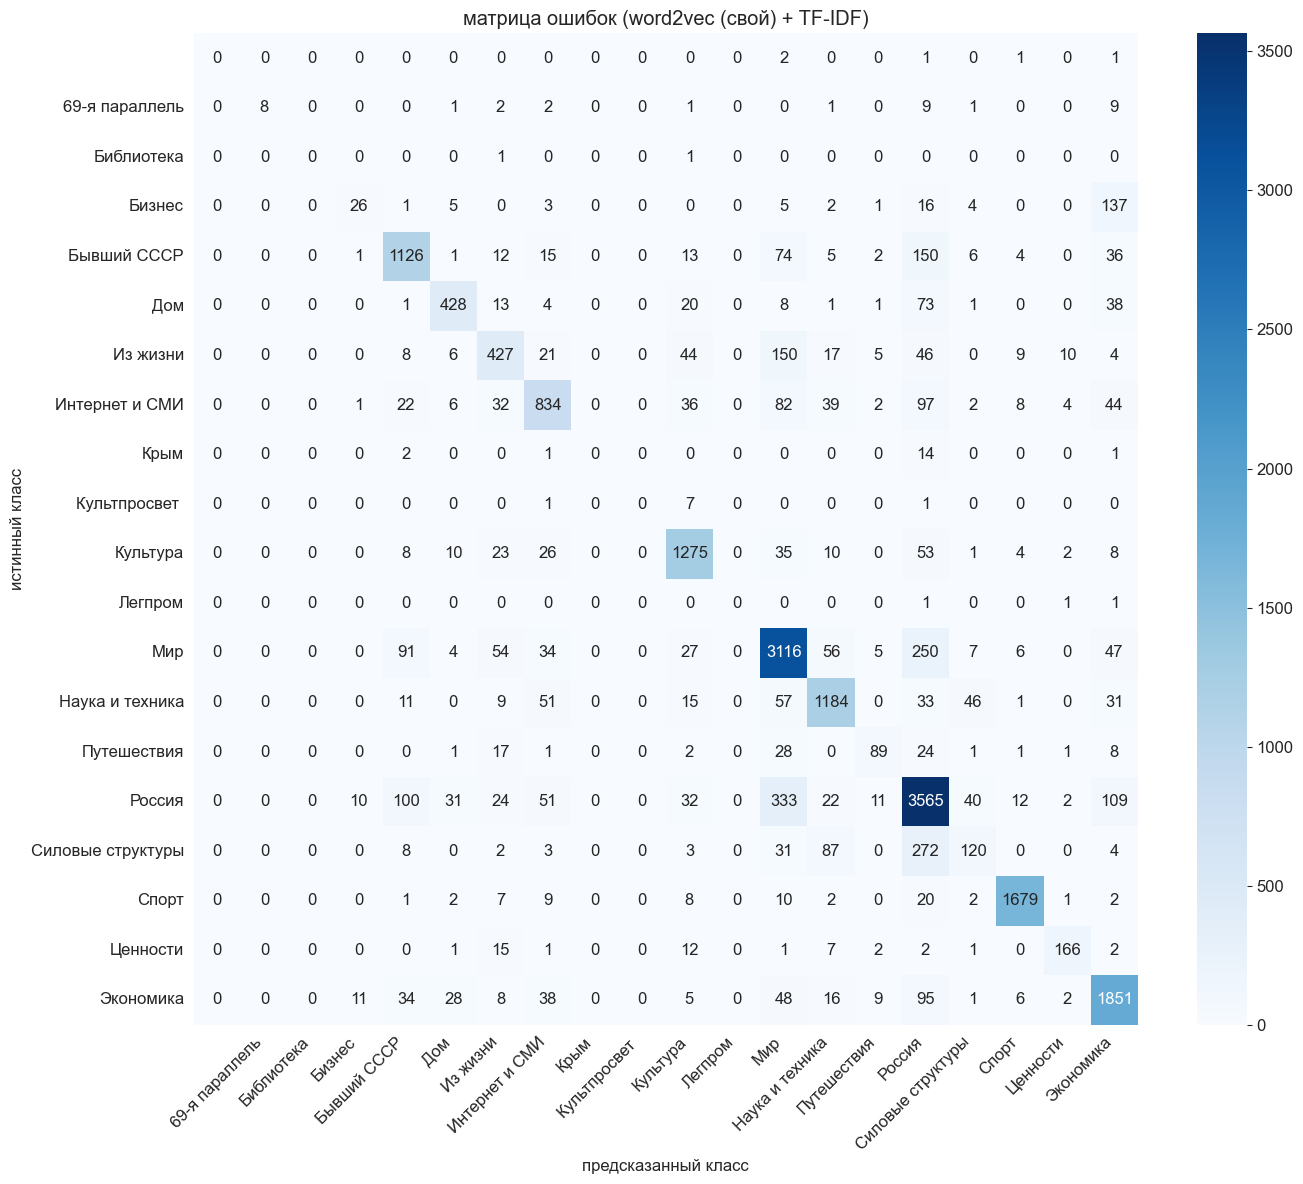

In [26]:
cm = confusion_matrix(y_test, y_pred_best, labels=sorted(y_test.unique()))

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique()),
)
plt.title(f'матрица ошибок ({best_test_name})')
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. анализ ошибок

посмотрим, на каких классах модель больше всего ошибается и какие классы путает между собой.

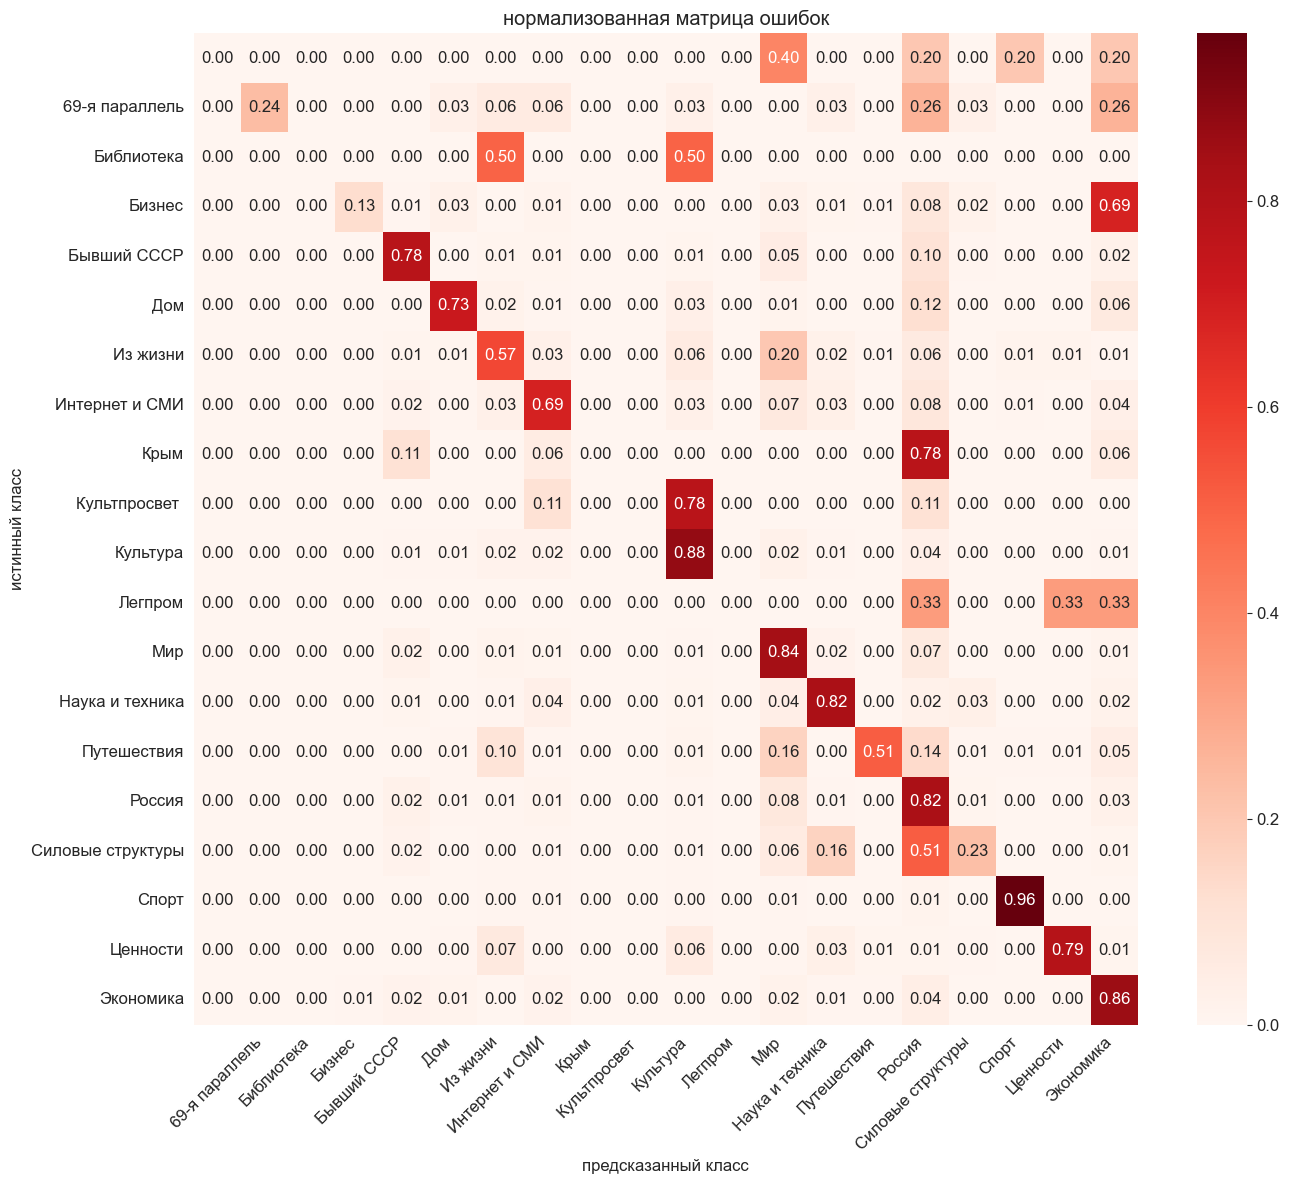

In [27]:
cm_norm = confusion_matrix(
    y_test, y_pred_best,
    labels=sorted(y_test.unique()),
    normalize='true',
)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Reds',
    xticklabels=sorted(y_test.unique()),
    yticklabels=sorted(y_test.unique()),
)
plt.title('нормализованная матрица ошибок')
plt.xlabel('предсказанный класс')
plt.ylabel('истинный класс')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
report = classification_report(y_test, y_pred_best, output_dict=True)
class_f1 = {
    k: v['f1-score']
    for k, v in report.items()
    if k not in ['accuracy', 'macro avg', 'weighted avg']
}

sorted_classes = sorted(class_f1.items(), key=lambda x: x[1])

print('классы с худшим f1-score:')
for cls, f1 in sorted_classes[:5]:
    count = (y_test == cls).sum()
    print(f'  {cls:25s}: f1={f1:.3f} (примеров: {count})')

print(f'\nклассы с лучшим f1-score:')
for cls, f1 in sorted_classes[-5:]:
    count = (y_test == cls).sum()
    print(f'  {cls:25s}: f1={f1:.3f} (примеров: {count})')

классы с худшим f1-score:
                           : f1=0.000 (примеров: 5)
  Библиотека               : f1=0.000 (примеров: 2)
  Крым                     : f1=0.000 (примеров: 18)
  Культпросвет             : f1=0.000 (примеров: 9)
  Легпром                  : f1=0.000 (примеров: 3)

классы с лучшим f1-score:
  Наука и техника          : f1=0.820 (примеров: 1438)
  Экономика                : f1=0.825 (примеров: 2152)
  Ценности                 : f1=0.832 (примеров: 210)
  Культура                 : f1=0.863 (примеров: 1455)
  Спорт                    : f1=0.967 (примеров: 1743)


видно что хуже всего модель справляется с редкими классами (мало примеров) и с классами, которые семантически близки (типа "Россия" и "Бывший СССР" - похожие тексты). это ожидаемо - эмбеддинги усредняют слова и теряют тонкие различия между похожими категориями.

## 9. выводы

1. **word2vec эмбеддинги** обученые на наших данных дают адекватные результаты - most_similar и doesnt_match работают правильно, слова из одной тематики группируются на PCA визуализации

2. **сравнение эмбеддингов**: наш word2vec показал лучший результат (acc=0.796, f1_macro=0.510 на тесте), несмотря на наименьшее покрытие (~32%). navec на втором месте (acc=0.769), rusvectores - на третьем (acc=0.742). доменная специфика (обучение на новостях) оказалась важнее размера словаря

3. **TF-IDF взвешивание** дало заметный прирост f1_macro на валидации (0.496 -> 0.508) и на тесте (0.510 -> 0.515), хотя accuracy чуть просела. значит TF-IDF помогает лучше учитывать информативные слова

4. **основные ошибки** - на редких классах с малым числом примеров (Библиотека, Крым, Легпром - f1=0.0), а лучше всего классифицируются крупные категории (Спорт, Культура). для улучшения можно попробовать:
   - обучить word2vec на полном датасете (а не на 100к)
   - использовать fastText вместо word2vec (учитывает подслова)
   - использовать более сложные модели (LSTM, трансформеры)

5. все модели используют фиксированый random_state=42 для воспроизводимости